In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('../data/SuperStoreOrders.csv')

In [3]:
df

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.1400,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.0360,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.6400,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.0550,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.7700,4.70,Medium,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,31-12-2014,4/1/2015,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,31-12-2014,5/1/2015,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,31-12-2014,2/1/2015,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,31-12-2014,6/1/2015,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  str    
 1   order_date      51290 non-null  str    
 2   ship_date       51290 non-null  str    
 3   ship_mode       51290 non-null  str    
 4   customer_name   51290 non-null  str    
 5   segment         51290 non-null  str    
 6   state           51290 non-null  str    
 7   country         51290 non-null  str    
 8   market          51290 non-null  str    
 9   region          51290 non-null  str    
 10  product_id      51290 non-null  str    
 11  category        51290 non-null  str    
 12  sub_category    51290 non-null  str    
 13  product_name    51290 non-null  str    
 14  sales           51290 non-null  str    
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null  float64
 1

In [5]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='mixed',
    dayfirst=True
)

In [7]:
df['ship_date'] = pd.to_datetime(
    df['ship_date'],
    format='mixed',
    dayfirst=True
)


In [8]:
df['sales'] = df['sales'].str.replace(',','')


In [9]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  str           
 1   order_date      51290 non-null  datetime64[us]
 2   ship_date       51290 non-null  datetime64[us]
 3   ship_mode       51290 non-null  str           
 4   customer_name   51290 non-null  str           
 5   segment         51290 non-null  str           
 6   state           51290 non-null  str           
 7   country         51290 non-null  str           
 8   market          51290 non-null  str           
 9   region          51290 non-null  str           
 10  product_id      51290 non-null  str           
 11  category        51290 non-null  str           
 12  sub_category    51290 non-null  str           
 13  product_name    51290 non-null  str           
 14  sales           51290 non-null  int64         
 15  quantity     

In [14]:
df['sales'].describe()

count    51290.000000
mean       246.498440
std        487.567175
min          0.000000
25%         31.000000
50%         85.000000
75%        251.000000
max      22638.000000
Name: sales, dtype: float64

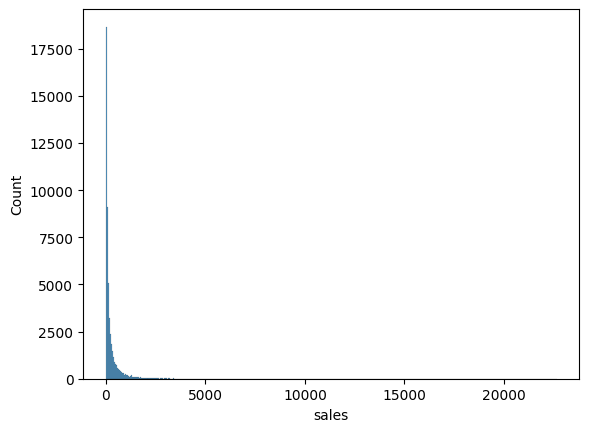

In [15]:
sns.histplot(df['sales'])
plt.show()

In [16]:
df['sales'].skew()

np.float64(8.13798050972221)

In [17]:
df['sales'].mean()

np.float64(246.49844024176252)

In [18]:
df['sales'].median()

np.float64(85.0)

In [20]:
df[
    [
        "sales",
        "profit",
        "quantity",
        "discount",
        "shipping_cost"
    ]
].corr(numeric_only=True)

,sales,profit,quantity,discount,shipping_cost
sales,1.000000,0.485944,0.313580,-0.086728,0.768075
profit,0.485944,1.000000,0.104743,-0.316375,0.357033
quantity,0.313580,0.104743,1.000000,-0.019875,0.272649
discount,-0.086728,-0.316375,-0.019875,1.000000,-0.079056
shipping_cost,0.768075,0.357033,0.272649,-0.079056,1.000000


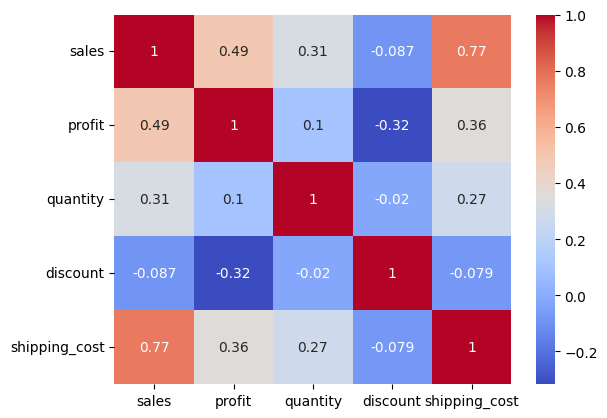

In [21]:
sns.heatmap(
    df[
    [
        "sales",
        "profit",
        "quantity",
        "discount",
        "shipping_cost"
    ]
].corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.show()

In [22]:
df['sales'].describe()

count    51290.000000
mean       246.498440
std        487.567175
min          0.000000
25%         31.000000
50%         85.000000
75%        251.000000
max      22638.000000
Name: sales, dtype: float64

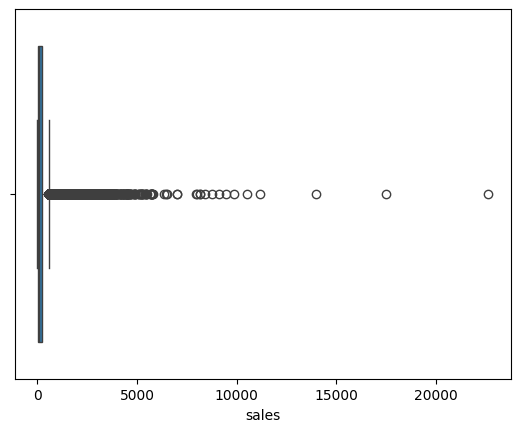

In [23]:
sns.boxplot(x=df['sales'])
plt.show()

In [24]:
df.groupby('category')['sales'].sum().sort_values(ascending=False)

category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: sales, dtype: int64

In [25]:
df.groupby('category')['profit'].sum().sort_values(ascending=False)

category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          286782.25380
Name: profit, dtype: float64

In [26]:
df.groupby('region')['sales'].sum().sort_values(ascending=False)

region
Central           2822399
South             1600960
North             1248192
Oceania           1100207
Southeast Asia     884438
North Asia         848349
EMEA               806184
Africa             783776
Central Asia       752839
West               725514
East               678834
Caribbean          324281
Canada              66932
Name: sales, dtype: int64